<a href="https://colab.research.google.com/github/VladimirSharaP/Dogs_Classifier/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade keras==3.0

В 2021 году появилась вторая версия модели EfficientNetV2 (https://arxiv.org/pdf/2104.00298.pdf), которая была добавлена в Keras.

Подключение библиотек

In [ ]:
import keras
print(keras.__version__)

3.4.1


In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

from tensorflow import data as tf_data
import os
import keras
from keras import layers
os.environ["KERAS_BACKEND"] = "tensorflow"

IMAGE_SIZE = (224, 224) # Размер определен выбором модели
BATCH_SIZE = 128

Подготовка данных

In [ ]:
!wget https://storage.yandexcloud.net/academy.ai/stanford_dogs.zip

--2024-09-30 07:00:30--  https://storage.yandexcloud.net/academy.ai/stanford_dogs.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 774907490 (739M) [application/x-zip-compressed]
Saving to: ‘stanford_dogs.zip’

stanford_dogs.zip   100%[===================>] 739.01M  30.6MB/s    in 26s     

2024-09-30 07:00:57 (28.4 MB/s) - ‘stanford_dogs.zip’ saved [774907490/774907490]



In [ ]:
# Разархивируем датасета во временную папку 'temp'
!unzip -qo "stanford_dogs" -d ./dataset

# Папка с папками картинок, рассортированных по категориям
IMAGE_PATH = './dataset/'

In [ ]:
import numpy as np
import shutil
import random

# Определяем список имен классов
CLASS_LIST = sorted(os.listdir(IMAGE_PATH))

# Определяем количества классов
CLASS_COUNT = len(CLASS_LIST)

def delete_folders_except_random(directory, num_to_keep=10):
    # Получаем список всех папок в указанной директории
    CLASS_LIST = sorted(os.listdir(IMAGE_PATH))

    # Случайным образом выбираем папки, которые нужно оставить
    folders_to_keep = random.sample(CLASS_LIST, num_to_keep)

    # Удаляем все папки, кроме выбранных
    for folder in CLASS_LIST:
        if folder not in folders_to_keep:
            folder_path = os.path.join(directory, folder)
            shutil.rmtree(folder_path)

# Пример использования
delete_folders_except_random(IMAGE_PATH)


In [ ]:
num_skipped = 0 # счетчик поврежденных файлов
for folder_name in os.listdir(IMAGE_PATH): # перебираем папки
    folder_path = os.path.join(IMAGE_PATH, folder_name) # склеиваем путь
    for fname in os.listdir(folder_path): # получаем список файлов в папке
        fpath = os.path.join(folder_path, fname) # получаем путь до файла
        try:
            fobj = open(fpath, "rb") # пытаемся открыть файл для бинарного чтения (rb)
            is_jfif = b"JFIF" in fobj.peek(10) # получаем первые 10 байт из файла и ищем в них бинарный вариант строки JFIF
        finally:
            fobj.close() # Закрываем файл

        if not is_jfif: # Если не нашли JFIF строку
            # Увеличиваем счетчик
            num_skipped += 1
            # Удаляем поврежденное изображение
            os.remove(fpath)

print(f"Удалено изображений: {num_skipped}")

Удалено изображений: 0


In [ ]:
train_ds, temp_ds = keras.utils.image_dataset_from_directory(
    IMAGE_PATH, # путь к папке с данными
    validation_split=0.2, # отщепляем 20% на проверочную выборку
    subset="both", # указываем, что необходимо вернуть кортеж из обучающей и проверочной выборок ("training", "validation" или "both")
    seed=42,  # воспроизводимость результата генерации (результаты с одинаковым числом - одинаковы),
    shuffle=True, # перемешиваем датасет
    image_size=IMAGE_SIZE, # размер генерируемых изображений
    batch_size=BATCH_SIZE, # размер мини-батча
)

val_batches = int(0.5 * len(temp_ds))  # 50% временной выборки для проверки, 50% для теста

val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

# Определяем список имен классов
CLASS_LIST = sorted(os.listdir(IMAGE_PATH))

# Определяем количества классов
CLASS_COUNT = len(CLASS_LIST)

# Вывод результата
print(f'Количество классов: {CLASS_COUNT}')
print(f'Метки классов: {CLASS_LIST}')

print(f"Train dataset size: {len(train_ds)} batches")
print(f"Validation dataset size: {len(val_ds)} batches")
print(f"Test dataset size: {len(test_ds)} batches")

Found 1622 files belonging to 10 classes.
Using 1298 files for training.
Using 324 files for validation.
Количество классов: 10
Метки классов: ['Affenpinscher', 'Basset', 'Brabancon_griffon', 'Dhole', 'English_springer', 'German_short-haired_pointer', 'Kelpie', 'Miniature_schnauzer', 'Samoyed', 'Scotch_terrier']
Train dataset size: 11 batches
Validation dataset size: 1 batches
Test dataset size: 2 batches


Исходные изображения и их классы

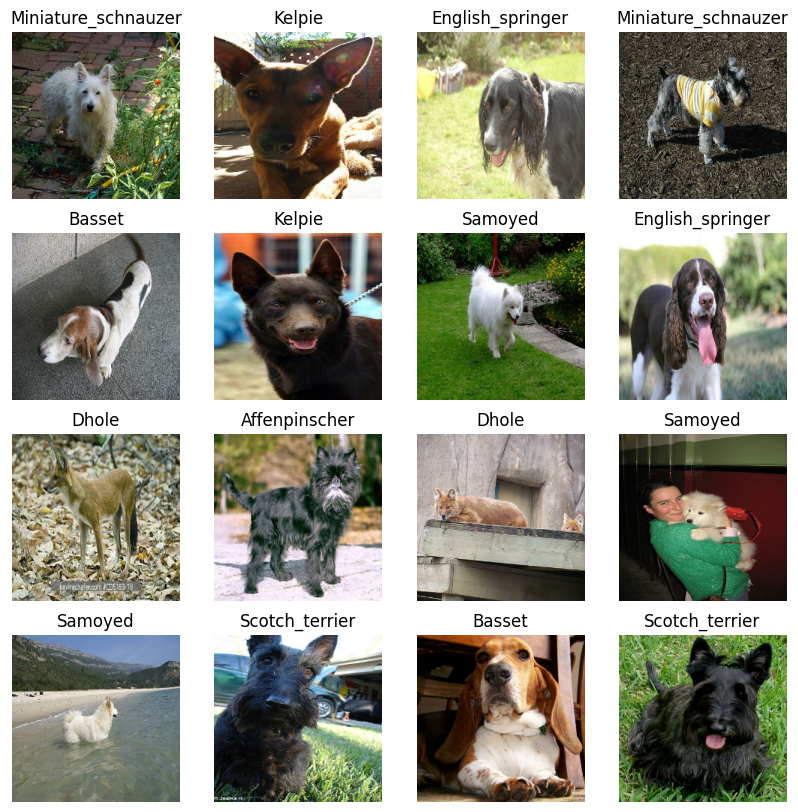

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(4): # берем первый батч обучающей выборки
    for i in range(16): # отрисуем первые 16 картинок батча
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(keras.utils.img_to_array(images[i]).astype("uint8"))
        plt.title(CLASS_LIST[labels[i]]) # покажем метки
        plt.axis("off") # отключаем отображение осей

Аргументация данных

In [ ]:
img_augmentation_layers = [
    layers.RandomRotation(factor=0.15), # Вращаем изображение в пределах 15%
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1), # Сдвиг на 10% по вертикали и горизонтали
    layers.RandomFlip(), # Отражение по вертикали и горизонтали
    layers.RandomContrast(factor=0.1), # Изменяем контрастность на 10%
]


def img_augmentation(images):
    # Слои - это функции, которые мы последовательно применяем к входным данным
    for layer in img_augmentation_layers:
        images = layer(images)
    return images

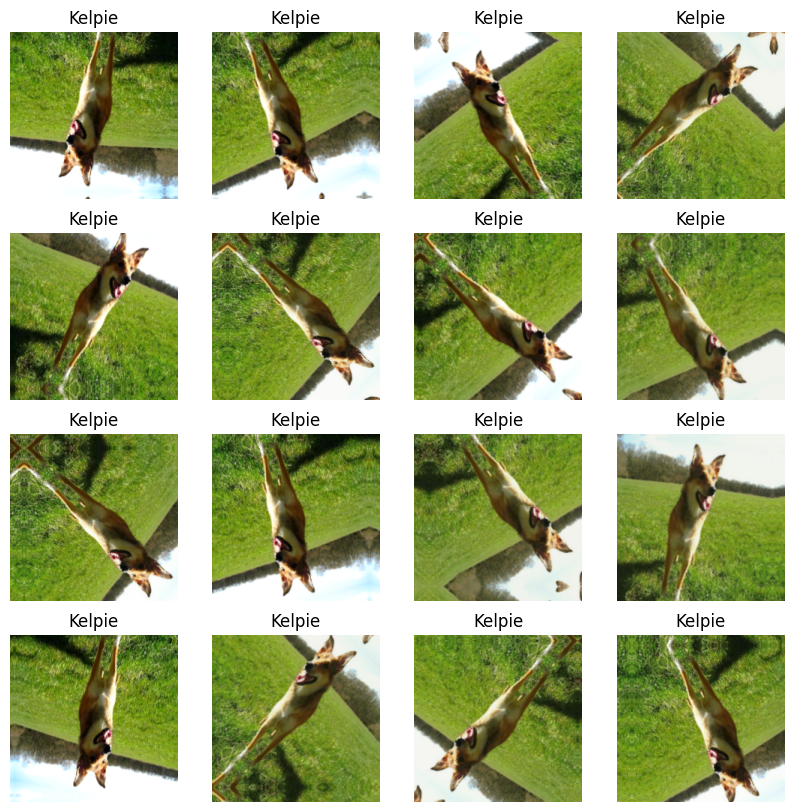

In [ ]:
plt.figure(figsize=(10, 10))
for images, label in train_ds.take(3):
    for i in range(16):
        augmented_images = img_augmentation(images[0])
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(keras.utils.img_to_array(augmented_images).astype("uint8")) # Преобразуем картинку в тензор, теперь уже без NumPy
        plt.title("{}".format(CLASS_LIST[label[0]])) # Вывод метки
        plt.axis("off")

In [ ]:
# Применяем `img_augmentation` к обучающей выборке

train_ds = train_ds.map(
    lambda img, label: (img_augmentation(img), keras.ops.one_hot(label, CLASS_COUNT)), # One-hot кодирование
    num_parallel_calls=tf_data.AUTOTUNE, # число потоков для обработки в map (автонастройка зависит от возможностей процессора)
)


val_ds = val_ds.map(
    lambda img, label: (img, keras.ops.one_hot(label, CLASS_COUNT)), # One-hot кодирование
    num_parallel_calls=tf_data.AUTOTUNE, # число потоков для обработки в map (автонастройка зависит от возможностей процессора)
)

test_ds = test_ds.map(
    lambda img, label: (img, keras.ops.one_hot(label, CLASS_COUNT)), # One-hot кодирование
    num_parallel_calls=tf_data.AUTOTUNE, # число потоков для обработки в map (автонастройка зависит от возможностей процессора)
)


# Предварительная выборка примеров в память GPU или оперативную память
# Помогает максимально эффективно использовать графический процессор
train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
val_ds = val_ds.prefetch(tf_data.AUTOTUNE)
test_ds = test_ds.prefetch(tf_data.AUTOTUNE)

Вспомогательная функция для построения графика обучения модели

In [ ]:
def show_plot(history):
    acc = history.history['acc']
    epochs = range(1, len(acc) + 1)
    val_acc = history.history['val_acc']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)
    plt.plot(epochs, acc, 'r', label='Точность на обучающей выборке')
    plt.plot(epochs, val_acc, 'b', label='Точность на проверочной выборке')
    plt.title('График точности на обучающей и проверочной выборках')
    plt.legend()
    plt.figure()
    plt.plot(epochs, loss, 'r', label='Потери на обучающей выборке')
    plt.plot(epochs, val_loss, 'b', label='Потери на проверочной выборке')
    plt.title('График потерь на обучающей и проверочной выборках')
    plt.legend()
    plt.show()

Настройка и обучение модели

In [ ]:
import tensorflow as tf
def build_model(num_classes):
    inputs = layers.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))

    model = keras.applications.EfficientNetV2B0(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs,
        classes=10,
    )

    # Заморозка предобученных весов
    model.trainable = False

    # Замена верхних слоев
    x = layers.GlobalAveragePooling2D(name="avg_pool")(model.output)
    x = layers.BatchNormalization()(x)

    top_dropout_rate = 0.2
    x = layers.Dropout(top_dropout_rate, name="top_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="pred")(x)

    # Компилируем
    model = keras.Model(inputs, outputs, name="EfficientNetV2")
    optimizer = keras.optimizers.Adam(learning_rate=1e-2)
    model.compile(
        optimizer=optimizer, loss="categorical_crossentropy", metrics=["acc"]
    )
    return model

In [ ]:
epochs = 10

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath = 'best_model_pretrain.keras',
                             monitor = 'val_acc',
                             save_best_only = True,
                             mode = 'max',
                             verbose = 0)
]

model = build_model(num_classes=CLASS_COUNT)

history = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)


Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 124s 9s/step - acc: 0.5928 - loss: 1.4909 - val_acc: 0.9766 - val_loss: 0.1269
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 140s 9s/step - acc: 0.8870 - loss: 0.4980 - val_acc: 0.9609 - val_loss: 0.0843
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 108s 9s/step - acc: 0.9097 - loss: 0.4127 - val_acc: 0.9844 - val_loss: 0.0607
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 104s 9s/step - acc: 0.9111 - loss: 0.3408 - val_acc: 0.9688 - val_loss: 0.0625
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 152s 9s/step - acc: 0.9197 - loss: 0.3441 - val_acc: 0.9844 - val_loss: 0.0464
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 107s 9s/step - acc: 0.9344 - loss: 0.2607 - val_acc: 0.9766 - val_loss: 0.0668
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 103s 9s/step - acc: 0.9280 - loss: 0.2869 - val_acc: 0.9844 - val_loss: 0.0587
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 107s 9s/step - acc: 0.9182 - loss: 0.3136 - val_acc: 0.9844 - val_loss: 0.0674
Epoch 9/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 142s 9s/step - acc: 0.9130

Анализ результатов

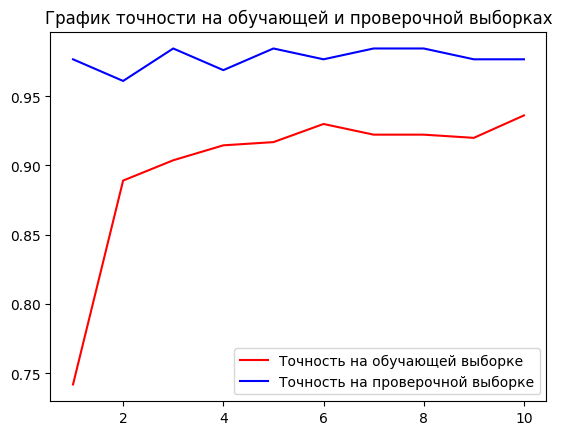

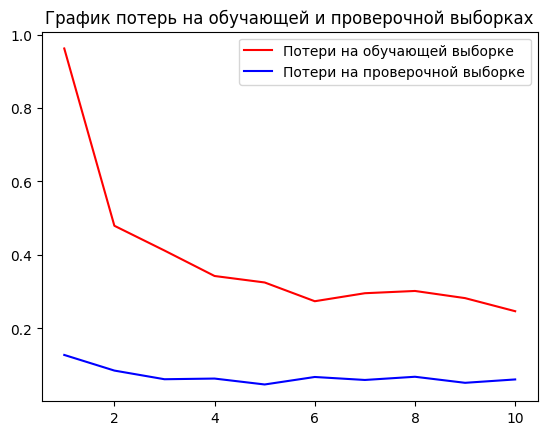

In [ ]:
show_plot(history)

In [ ]:
from google.colab import files
files.download('best_model_pretrain.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model = keras.models.load_model('best_model_pretrain.keras')

loss, accuracy = model.evaluate(test_ds)
print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - acc: 0.9624 - loss: 0.1120
Test Loss: 0.11308078467845917
Test Accuracy: 0.9591836929321289
